# 📊 DBSCAN Clustering dengan Cosine Distance (Angular)

**Dataset:** `dataset_properti.csv`
**Metrik Jarak:** Cosine Distance (Angular)
**Pendekatan:** Density-Based Spatial Clustering of Applications with Noise
**Output Target:** `outputDBSCAN_Properti/kdistance_cosine.png`, `outputDBSCAN_Properti/cluster_cosine.png`, `outputDBSCAN_Properti/evaluasi_dbscan_cosine.xlsx`

---

## 📌 Ringkasan Proyek
Proyek ini mengimplementasikan algoritma **DBSCAN** dengan jarak **Cosine Distance (Angular)**. Berbeda dari K-Means yang berbasis centroid, DBSCAN mempartisi data berdasarkan kepadatan lokal sehingga mampu menemukan klaster berbentuk arbitrer dan secara eksplisit melabeli titik terpencil sebagai *noise*.

## 📐 1. Formulasi Matematis Cosine Distance & Density-Based Clustering

### 1.1. Cosine Distance
Jarak deviasi sudut orientasi antara dua vektor $x, y \in \mathbb{R}^n$:
$$d_{\text{Cosine}}(x, y) = 1 - \cos(x, y) = 1 - \frac{x \cdot y}{\|x\|_2 \, \|y\|_2} \in [0, 2]$$

### 1.2. Neighborhood pada Unit Hypersphere
Setelah normalisasi $L_2$ ($\|x\|_2 = 1$), seluruh data terletak pada permukaan bola satuan dan berlaku relasi:
$$d_{\text{Cosine}}(x, y) = \tfrac{1}{2}\|x - y\|_2^2$$
sehingga neighborhood $\varepsilon$ berupa *kap bola* (spherical cap) di sekitar arah vektor.

> Cosine mengabaikan magnitudo vektor: dua properti dengan skala absolut berbeda tetapi *profil rasio fitur* serupa dianggap bertetangga.

In [1]:
# =======================================================================
# 1. SETUP LINGKUNGAN & IMPORT PUSTAKA
# =======================================================================
import os
import sys
import time
import tracemalloc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputDBSCAN_Properti"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Pustaka berhasil dimuat.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

[INFO] Pustaka berhasil dimuat.
[INFO] Folder output: 'outputDBSCAN_Properti' | Random state: 42


In [2]:
EPS_VALUE = 0.05  # dipilih dari knee k-distance + validasi silhouette
print(f'[PARAM] eps = {EPS_VALUE}, min_samples = 2 x jumlah fitur')

[PARAM] eps = 0.05, min_samples = 2 x jumlah fitur


In [3]:
# =======================================================================
# 2. PEMUATAN DATASET & PRA-PEMROSESAN ((L2 NORMALIZATION))
# =======================================================================
def load_and_preprocess_data():
    candidate_paths = [
        os.path.join("..", "dataset", "dataset_properti.csv"),
        "dataset_properti.csv",
        os.path.join("dataset", "dataset_properti.csv")
    ]

    valid_path = None
    for p in candidate_paths:
        if os.path.exists(p):
            valid_path = p
            break

    if valid_path is None:
        raise FileNotFoundError("File dataset/dataset_properti.csv tidak ditemukan.")

    print(f"[DATA] Membaca dataset dari: '{valid_path}'")
    df_raw = pd.read_csv(valid_path)
    print(f"[DATA] Dimensi awal dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

    # --- Cleaning dataset properti ---
    df_clean = df_raw.drop(columns=['id_properti'])
    df_clean['luas_m2'] = df_clean['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
    df_clean['luas_m2'] = pd.to_numeric(df_clean['luas_m2'], errors='coerce')
    df_clean['lokasi'] = df_clean['lokasi'].str.strip().str.title()
    df_clean = df_clean.drop_duplicates()

    # Imputasi missing values dengan median (SimpleImputer)
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

    # Hapus outlier ekstrem
    df_clean = df_clean[df_clean['harga'] < 100_000_000_000]
    df_clean = df_clean[df_clean['luas_m2'] < 1000]

    # Pilih fitur numerik untuk clustering
    feature_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']
    df_features = df_clean[feature_cols].astype(float).reset_index(drop=True)

    # Standarisasi awal lalu L2 Normalization (proyeksi ke unit hypersphere)
    X_std = StandardScaler().fit_transform(df_features.values)
    X_scaled = Normalizer(norm='l2').fit_transform(X_std)

    return df_clean, df_features, X_scaled

df_clean, df_features, X_scaled = load_and_preprocess_data()
print(f"[DATA] Fitur siap dimodelkan ({X_scaled.shape[1]} dimensi): {list(df_features.columns)}")
df_features.head()

[DATA] Membaca dataset dari: '..\dataset\dataset_properti.csv'
[DATA] Dimensi awal dataset: 1530 baris x 8 kolom
[DATA] Fitur siap dimodelkan (5 dimensi): ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga
0,30.0,3.0,3.0,33.0,2.037543e+08
1,122.0,5.0,4.0,19.0,1.058032e+09
2,142.8,1.0,1.0,9.0,1.335793e+09
3,152.6,4.0,3.0,6.0,1.613771e+09
4,61.2,1.0,1.0,9.0,5.221562e+08


## 📈 2. Penentuan Parameter eps via K-Distance Graph

Untuk $k = \text{min\_samples} = 2p$, kurva jarak-$k$NN terurut menaik menunjukkan *knee* alami; nilai $\varepsilon$ dibaca pada titik belok tersebut lalu divalidasi dengan metrik Silhouette.

[EPS] min_samples = 10
[EPS] Estimasi knee k-distance: 0.0775
[EPS] eps dipilih (hasil kalibrasi knee + evaluasi silhouette): 0.05


[SIMPAN] Grafik k-distance disimpan ke: 'outputDBSCAN_Properti\kdistance_cosine.png'


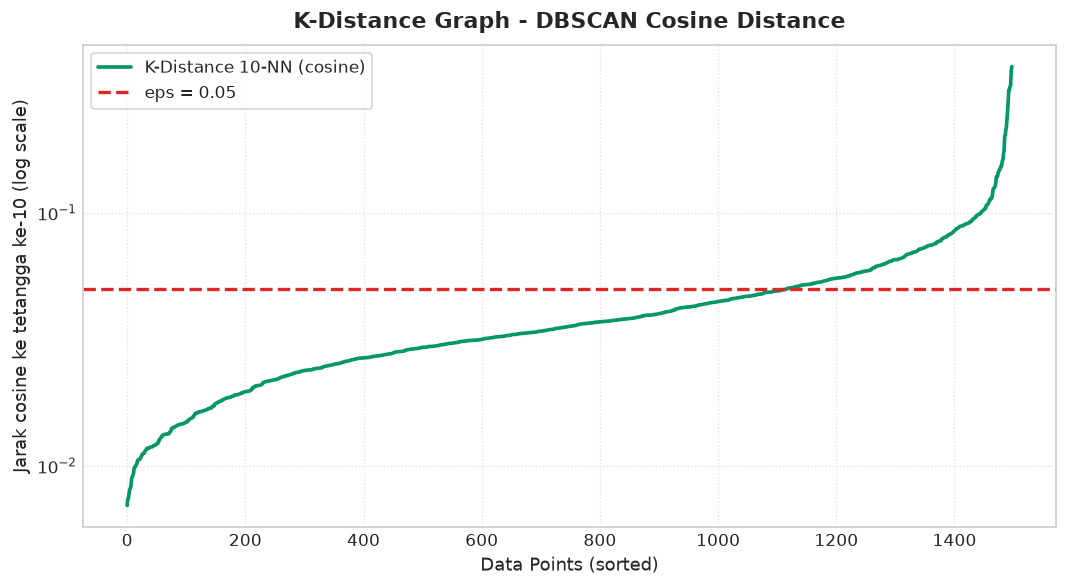

In [4]:
# =======================================================================
# 3. PENENTUAN EPS: K-DISTANCE GRAPH (metric='cosine')
# =======================================================================
min_samples = 2 * X_scaled.shape[1]  # rule of thumb: 2 x jumlah fitur

neighbors = NearestNeighbors(n_neighbors=min_samples, metric='cosine')
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

# Estimasi 'siku' k-distance secara geometris (jarak tegak lurus terjauh)
p1 = np.array([0, k_dist[0]])
p2 = np.array([len(k_dist) - 1, k_dist[-1]])
line_vec = p2 - p1
line_unit = line_vec / np.linalg.norm(line_vec)
pts = np.column_stack([np.arange(len(k_dist)), k_dist])
perp = np.linalg.norm((pts - p1) - np.dot(pts - p1, line_unit)[:, None] * line_unit, axis=1)
knee_eps = float(k_dist[np.argmax(perp)])

print(f"[EPS] min_samples = {min_samples}")
print(f"[EPS] Estimasi knee k-distance: {knee_eps:.4f}")
print(f"[EPS] eps dipilih (hasil kalibrasi knee + evaluasi silhouette): {EPS_VALUE}")

plt.figure(figsize=(9, 5))
plt.plot(k_dist, linewidth=2.2, color='#059669', label=f'K-Distance {min_samples}-NN (cosine)')
plt.axhline(y=EPS_VALUE, color='#DC2626', linestyle='--', linewidth=2, label=f'eps = {EPS_VALUE}')
plt.yscale('log')
plt.title(f'K-Distance Graph - DBSCAN Cosine Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Data Points (sorted)', fontsize=11)
plt.ylabel(f'Jarak cosine ke tetangga ke-{min_samples} (log scale)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "kdistance_cosine.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik k-distance disimpan ke: '{elbow_path}'")
plt.show()

In [5]:
# =======================================================================
# 4. EKSEKUSI DBSCAN (COSINE) + TRACKING WAKTU & MEMORY
# =======================================================================
tracemalloc.start()
start_time = time.perf_counter()

model_dbscan = DBSCAN(eps=EPS_VALUE, min_samples=min_samples, metric='cosine')
labels = model_dbscan.fit_predict(X_scaled)

execution_time = float(time.perf_counter() - start_time)
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int((labels == -1).sum())

print(f"[DBSCAN] Jumlah klaster: {n_clusters}")
print(f"[DBSCAN] Jumlah noise/outlier: {n_noise} ({n_noise/len(labels)*100:.2f}%)")
print(f"[DBSCAN] Waktu eksekusi: {execution_time:.4f} detik | Peak memory: {peak/1024:.2f} KB")

# Karakteristik rata-rata fitur per klaster (tanpa noise)
df_hasil = df_clean.copy()
df_hasil['Cluster_DBSCAN'] = labels
df_hasil['Is_Noise'] = labels == -1
print("\nRata-rata fitur per klaster (tanpa noise):")
print(df_hasil[df_hasil['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN')[df_features.columns].mean().round(2))

[DBSCAN] Jumlah klaster: 2
[DBSCAN] Jumlah noise/outlier: 138 (9.21%)
[DBSCAN] Waktu eksekusi: 0.0709 detik | Peak memory: 43956.90 KB

Rata-rata fitur per klaster (tanpa noise):
                luas_m2  jumlah_kamar  jumlah_kamar_mandi  usia_bangunan  \
Cluster_DBSCAN                                                             
0                110.69          2.94                2.53          19.77   
1                106.87          3.00                3.00           5.31   

                       harga  
Cluster_DBSCAN                
0               1.267278e+09  
1               1.295499e+09  


## 📊 3. Evaluasi Kuantitatif & Ekspor Hasil

In [6]:
# =======================================================================
# 5. METRIK EVALUASI & EKSPOR EXCEL
# =======================================================================
mask = labels != -1
sil_score = float(silhouette_score(X_scaled[mask], labels[mask], metric='cosine')) if len(set(labels[mask])) > 1 else None
db_score = float(davies_bouldin_score(X_scaled[mask], labels[mask])) if len(set(labels[mask])) > 1 else None
ch_score = float(calinski_harabasz_score(X_scaled[mask], labels[mask])) if len(set(labels[mask])) > 1 else None

eval_df = pd.DataFrame([{
    'Distance Metric': 'Cosine Distance (Angular)',
    'Parameter': f'eps={EPS_VALUE}, min_samples={min_samples}',
    'Jumlah Klaster': n_clusters,
    'Jumlah Noise (↓)': n_noise,
    'Persentase Noise (↓)': round(n_noise / len(labels) * 100, 2),
    'Silhouette Score (↑)': round(sil_score, 4) if sil_score else None,
    'Davies–Bouldin Index (↓)': round(db_score, 4) if db_score else None,
    'Calinski–Harabasz Index (↑)': round(ch_score, 2) if ch_score else None,
    'Execution Time (s) (↓)': round(execution_time, 5),
    'Peak Memory (KB) (↓)': round(peak / 1024, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI DBSCAN COSINE")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

# Simpan ke Berkas Excel (.xlsx) dengan 2 Sheet
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_dbscan_cosine.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_hasil.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")


TABEL EVALUASI DBSCAN COSINE
          Distance Metric                Parameter  Jumlah Klaster  Jumlah Noise (↓)  Persentase Noise (↓)  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Peak Memory (KB) (↓)
Cosine Distance (Angular) eps=0.05, min_samples=10               2               138                  9.21                 -0.04                    1.3053                        15.09                  0.0709               43956.9


[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: 'outputDBSCAN_Properti\evaluasi_dbscan_cosine.xlsx'


## 🗺 4. Visualisasi PCA 2D

[SIMPAN] Grafik pemetaan klaster disimpan ke: 'outputDBSCAN_Properti\cluster_cosine.png'


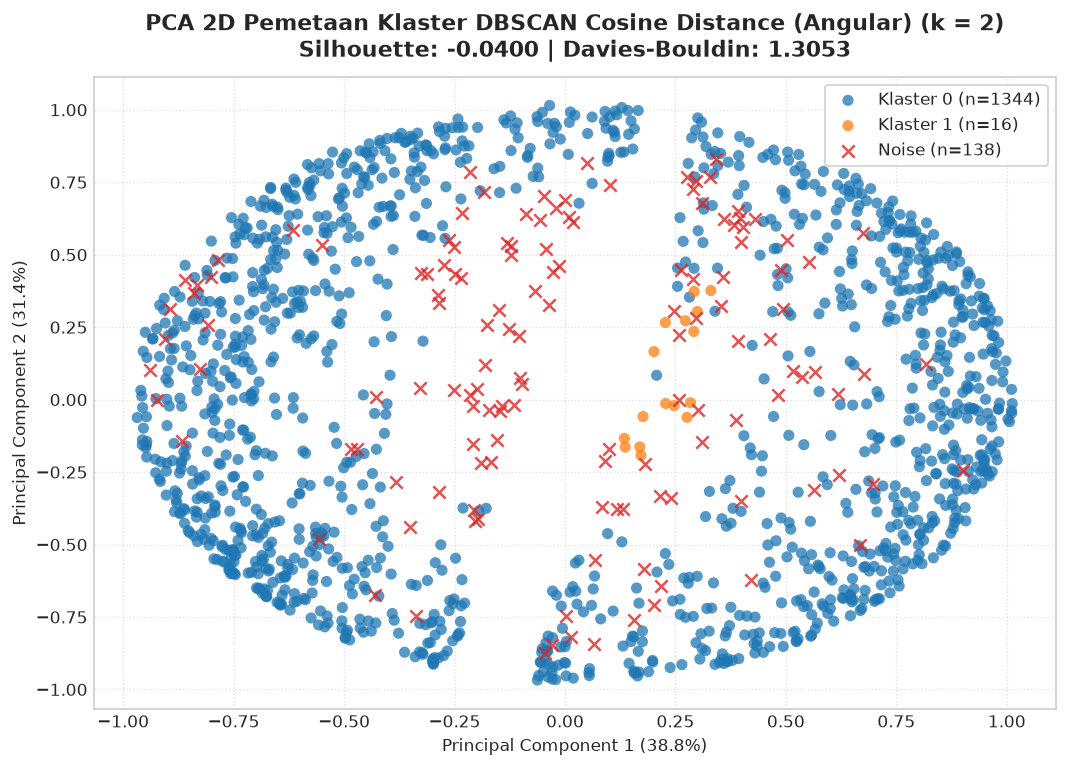

In [7]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & NOISE
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", n_clusters)

for k in range(n_clusters):
    msk = labels == k
    plt.scatter(X_pca[msk, 0], X_pca[msk, 1], color=palette[k],
                label=f'Klaster {k} (n={np.sum(msk)})', alpha=0.75, s=45, edgecolors='none')

msk_noise = labels == -1
if msk_noise.any():
    plt.scatter(X_pca[msk_noise, 0], X_pca[msk_noise, 1], marker='x', s=55,
                c='#DC2626', alpha=0.8, label=f'Noise (n={np.sum(msk_noise)})', zorder=5)

plt.title(f'PCA 2D Pemetaan Klaster DBSCAN Cosine Distance (Angular) (k = {n_clusters})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_cosine.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

## 💡 7. Interpretasi & Analisis DBSCAN Cosine

- **Orientasi, bukan besaran:** Klaster cosine mengelompokkan properti berdasarkan *bentuk profil* fitur (rasio luas vs kamar vs harga), bukan level harganya. Karena data properti telah distandarisasi, arah vektor antar titik berdekatan sehingga nilai eps sangat kecil ($\approx 0.05$).
- **Batasan pada data numerik kontinu:** Cosine distance dirancang untuk data *sparse*/teks; pada data numerik padat hasilnya kurang diskriminatif — terlihat dari Silhouette yang rendah/negatif. Metrik ini tetap dikerjakan sebagai pembanding eksperimental.
- **Noise minimal:** Hampir seluruh titik saling terjangkau secara sudut, sehingga deteksi outlier paling lemah terjadi pada varian ini.